In [41]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [42]:
# read in the cleaned CSV with data from central valley stations
path = 'E:/Central Valley Fog/CV_all_rows_wind_codes_temp.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_all_rows_wind_codes_temp.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

           STATION_ID  LATITUDE  LONGITUDE                 DATE REPORT_TYPE  \
0         USM00074917   35.1170  -119.3000  1941-12-01 00:00:00         SAO   
1         USM00074917   35.1170  -119.3000  1941-12-01 01:00:00         SAO   
2         USM00074917   35.1170  -119.3000  1941-12-01 02:00:00         SAO   
3         USM00074917   35.1170  -119.3000  1941-12-01 03:00:00         SAO   
4         USM00074917   35.1170  -119.3000  1941-12-01 04:00:00         SAO   
...               ...       ...        ...                  ...         ...   
14495830  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00       FM-15   
14495831  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00       FM-15   
14495832  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00       FM-15   
14495833  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00       FM-15   
14495834  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00       FM-15   

          HourlyDewPointTemperature  HourlyDryBulbT

In [43]:
# Exclude days from April through October (months 4-10) in CV_rows
CV_rows = CV_rows[~CV_rows['month'].isin([4, 5, 6, 7, 8, 9, 10])]

print("CV_rows after removing April-October:", CV_rows.shape)

CV_rows after removing April-October: (6404926, 19)


In [44]:
CV_rows['HourlyDewpointDepression'] = (
    CV_rows['HourlyDryBulbTemperature'] - CV_rows['HourlyDewPointTemperature']
)

CV_rows[['HourlyDryBulbTemperature', 'HourlyDewPointTemperature', 'HourlyDewpointDepression']].head()

,HourlyDryBulbTemperature,HourlyDewPointTemperature,HourlyDewpointDepression
0,13.0,11.9,1.1
1,12.4,10.7,1.7
2,12.4,11.3,1.1
3,12.4,11.3,1.1
4,13.0,11.9,1.1


In [45]:
# Ensure wind direction is numeric; "000" is treated as calm (0, 0)
wd1 = pd.to_numeric(CV_rows["HourlyWindDirection"], errors="coerce")

# Unit-vector style components from wind direction
# 360 = north, 180 = south, 270 = west, 90 = east
# Determine the north-south component of the wind direction
CV_rows["wind_ns_component"] = np.where(
    wd1.eq(0) | wd1.isna(),
    0.0,
    np.cos(np.deg2rad(wd1))
)

# Determine west-east component of the wind direction
CV_rows["wind_we_component"] = np.where(
    wd1.eq(0) | wd1.isna(),
    0.0,
    np.sin(np.deg2rad(wd1))
)

CV_rows[["HourlyWindDirection", "wind_ns_component", "wind_we_component"]].head()

,HourlyWindDirection,wind_ns_component,wind_we_component
0,0.0,0.000000,0.000000
1,158.0,-0.927184,0.374607
2,0.0,0.000000,0.000000
3,225.0,-0.707107,-0.707107
4,225.0,-0.707107,-0.707107


In [46]:
# Classify each observation as up-valley or down-valley relative to valley angle = 330°
valley_angle = 330.0  # interpreted as the up-valley flow direction (toward 330°)

wd = pd.to_numeric(CV_rows["HourlyWindDirection"], errors="coerce")  # meteorological "from" direction
ws = pd.to_numeric(CV_rows["HourlyWindSpeed"], errors="coerce")

# Convert to "to" direction (direction wind is blowing toward)
wd_to = (wd + 180.0) % 360.0

# Signed alignment with valley axis (+ up-valley, - down-valley)
# cos(delta) > 0 means aligned with up-valley axis, < 0 means opposite (down-valley)
delta = np.deg2rad(wd_to - valley_angle)
valley_alignment = np.cos(delta)

# Optional speed-weighted along-valley component
CV_rows["valley_along_component"] = valley_alignment * ws

calm_mask = wd.eq(0) | ws.eq(0)  # "000" direction and/or zero speed => calm
missing_mask = wd.isna() | ws.isna()

# Classify each observation as "up_valley", "down_valley", "cross_valley", "calm", or "missing"
CV_rows["valley_wind_type"] = np.select(
    [
        missing_mask,
        calm_mask,
        valley_alignment > 0,
        valley_alignment < 0,
    ],
    [
        "missing",
        "calm",
        "up_valley",
        "down_valley",
    ],
    default="cross_valley",
)

# Quick station-level check of the counts of each valley wind type
station_valley_counts = (
    CV_rows.groupby(["STATION", "valley_wind_type"])
    .size()
    .unstack(fill_value=0)
)

station_valley_counts.head()

valley_wind_type,calm,down_valley,up_valley
STATION,,,
BAKERSFIELD AP,93181,160509,132605
BEALE AFB,70007,94808,152317
CASTLE AFB,124287,88552,89316
CHICO ARMY FLYING SCHOOL,61822,61995,74061
FRESNO,1350,13684,9917


In [47]:
# Print all column names from CV_rows

CV_rows.head()

,STATION_ID,LATITUDE,LONGITUDE,DATE,REPORT_TYPE,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyPrecipitation,HourlyPresentWeatherType,HourlySkyConditions,...,month,day,hour,minute,STATION,HourlyDewpointDepression,wind_ns_component,wind_we_component,valley_along_component,valley_wind_type
0,USM00074917,35.117,-119.3,1941-12-01 00:00:00,SAO,11.9,13.0,0.0,||00,BKN:06,...,12,1,0,0,GARDNER AAF,1.1,0.000000,0.000000,-0.000000,calm
1,USM00074917,35.117,-119.3,1941-12-01 01:00:00,SAO,10.7,12.4,0.0,||00,OVC:08,...,12,1,1,0,GARDNER AAF,1.7,-0.927184,0.374607,0.495134,up_valley
2,USM00074917,35.117,-119.3,1941-12-01 02:00:00,SAO,11.3,12.4,0.0,||00,OVC:08,...,12,1,2,0,GARDNER AAF,1.1,0.000000,0.000000,-0.000000,calm
3,USM00074917,35.117,-119.3,1941-12-01 03:00:00,SAO,11.3,12.4,0.0,||00,OVC:08,...,12,1,3,0,GARDNER AAF,1.1,-0.707107,-0.707107,0.129410,up_valley
4,USM00074917,35.117,-119.3,1941-12-01 04:00:00,SAO,11.9,13.0,0.0,||00,OVC:08,...,12,1,4,0,GARDNER AAF,1.1,-0.707107,-0.707107,0.129410,up_valley


In [48]:
# filtering based on precipitation
# filtering visibility threshold to identify outliers
CV_rows_dd_wind_filtered = CV_rows[
    (CV_rows["HourlyDewpointDepression"] < 4.6)
    & (CV_rows["HourlyWindSpeed"] < 2.000)
]

print("CV_filtered_rows:", CV_rows_dd_wind_filtered.shape)

CV_filtered_rows: (1750733, 24)


In [49]:
# filtering based on precipitation
# filtering visibility threshold to identify outliers
CV_rows_dd_filtered_5deg = CV_rows[
    (CV_rows["HourlyDewpointDepression"] < 4.6)
    & (CV_rows["HourlyVisibility"] < 1.000)
]

print("CV_filtered_rows:", CV_rows_dd_filtered_5deg.shape)

CV_filtered_rows: (246441, 24)


In [50]:
# filtering based on precipitation
# filtering visibility threshold to identify outliers
CV_rows_dd_filtered_4deg = CV_rows[
    (CV_rows["HourlyDewpointDepression"] < 4)
    & (CV_rows["HourlyVisibility"] < 1.000)
]

print("CV_filtered_rows:", CV_rows_dd_filtered_4deg.shape)

CV_filtered_rows: (245852, 24)


In [51]:
# filtering based on precipitation
# filtering visibility threshold to identify outliers
CV_rows_dd_filtered_3deg = CV_rows[
    (CV_rows["HourlyDewpointDepression"] < 3)
    & (CV_rows["HourlyVisibility"] < 1.000)
]

print("CV_filtered_rows:", CV_rows_dd_filtered_3deg.shape)

CV_filtered_rows: (242934, 24)


In [52]:
# filtering based on precipitation
# filtering visibility threshold to identify outliers
CV_rows_dd_filtered_2deg = CV_rows[
    (CV_rows["HourlyDewpointDepression"] < 2)
    & (CV_rows["HourlyVisibility"] < 1.000)
]

print("CV_filtered_rows:", CV_rows_dd_filtered_2deg.shape)

CV_filtered_rows: (233179, 24)


In [53]:
# filtering based on precipitation
# filtering visibility threshold to identify outliers
CV_rows_dd_filtered_1deg = CV_rows[
    (CV_rows["HourlyDewpointDepression"] < 1)
    & (CV_rows["HourlyVisibility"] < 1.000)
]

print("CV_filtered_rows:", CV_rows_dd_filtered_1deg.shape)

CV_filtered_rows: (181694, 24)


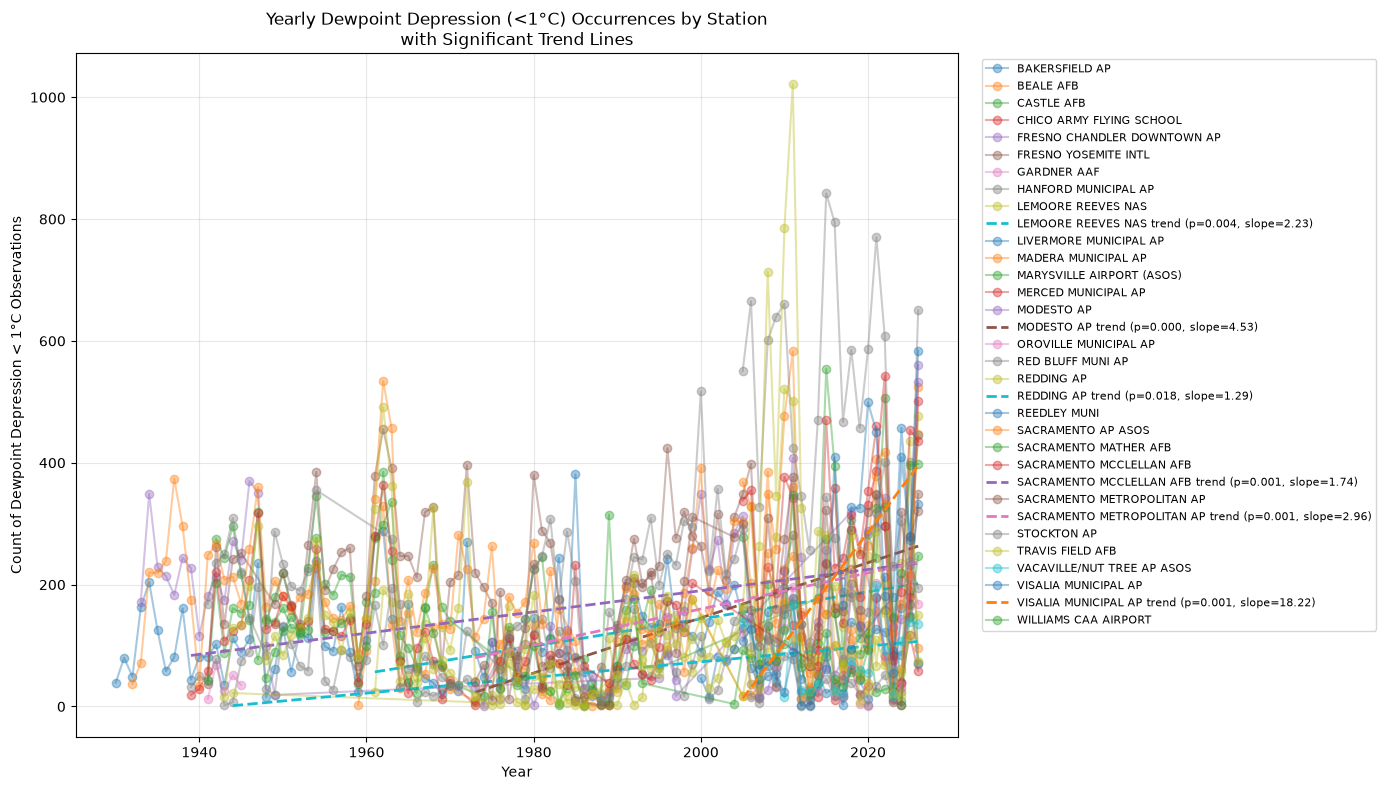

In [54]:
# Plot dewpoint depression occurrences per year for each station (CV_rows_dd_filtered_1deg)
# Fit and plot trend lines only for stations with statistically significant trends (p < 0.05)

yearly_counts = (
    CV_rows_dd_filtered_1deg.groupby(["STATION", "year"])
    .size()
    .reset_index(name="count")
)

stations = yearly_counts["STATION"].unique()

fig, ax = plt.subplots(figsize=(14, 8))

for station in stations:
    station_data = yearly_counts[yearly_counts["STATION"] == station].sort_values("year")

    if len(station_data) < 3:
        continue

    x = station_data["year"].values
    y = station_data["count"].values

    # Plot the raw yearly counts
    ax.plot(x, y, marker='o', linestyle='-', alpha=0.4, label=f"{station}")

    # Fit linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    # Only plot trend line if significant (p < 0.05)
    if p_value < 0.05:
        trend_y = slope * x + intercept
        ax.plot(x, trend_y, linestyle='--', linewidth=2,
                label=f"{station} trend (p={p_value:.3f}, slope={slope:.2f})")

ax.set_xlabel("Year")
ax.set_ylabel("Count of Dewpoint Depression < 1°C Observations")
ax.set_title("Yearly Dewpoint Depression (<1°C) Occurrences by Station\nwith Significant Trend Lines")
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

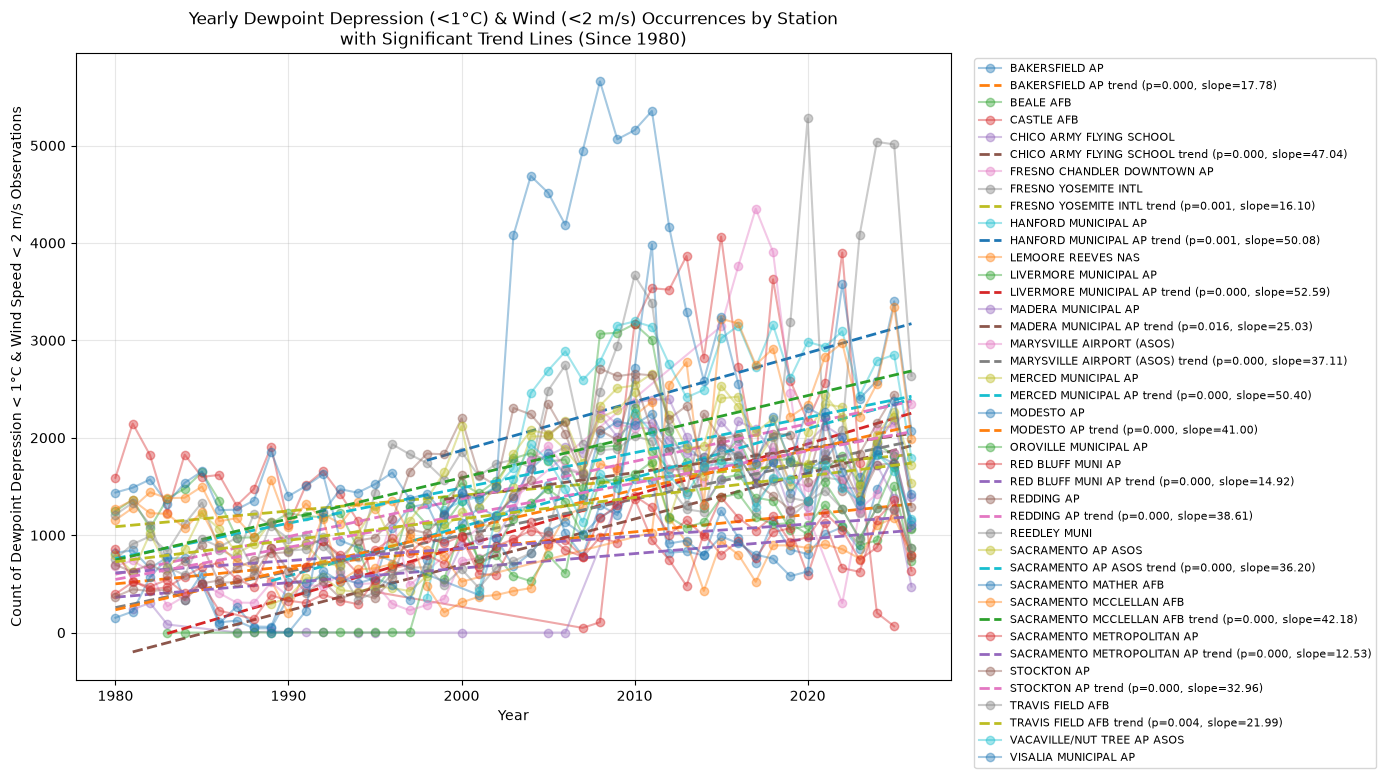

In [55]:
# Plot dewpoint depression occurrences per year for each station (CV_rows_dd_wind_filtered)
# Fit and plot trend lines only for stations with statistically significant trends (p < 0.05), since 1980

yearly_counts_wind = (
    CV_rows_dd_wind_filtered[CV_rows_dd_wind_filtered['year'] >= 1980]
    .groupby(["STATION", "year"])
    .size()
    .reset_index(name="count")
)

stations_wind = yearly_counts_wind["STATION"].unique()

fig, ax = plt.subplots(figsize=(14, 8))

for station in stations_wind:
    station_data = yearly_counts_wind[yearly_counts_wind["STATION"] == station].sort_values("year")

    if len(station_data) < 3:
        continue

    x = station_data["year"].values
    y = station_data["count"].values

    # Plot the raw yearly counts
    ax.plot(x, y, marker='o', linestyle='-', alpha=0.4, label=f"{station}")

    # Fit linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    # Only plot trend line if significant (p < 0.05)
    if p_value < 0.05:
        trend_y = slope * x + intercept
        ax.plot(x, trend_y, linestyle='--', linewidth=2,
                label=f"{station} trend (p={p_value:.3f}, slope={slope:.2f})")

ax.set_xlabel("Year")
ax.set_ylabel("Count of Dewpoint Depression < 1°C & Wind Speed < 2 m/s Observations")
ax.set_title("Yearly Dewpoint Depression (<1°C) & Wind (<2 m/s) Occurrences by Station\nwith Significant Trend Lines (Since 1980)")
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [56]:
# Compare CV_rows to CV_rows_dd_wind_filtered to determine the number of days/observations with optimal fog conditions
total_obs = CV_rows.shape[0]
optimal_obs = CV_rows_dd_wind_filtered.shape[0]

print(f"Total observations: {total_obs}")
print(f"Observations with optimal fog conditions (dewpoint depression < 4.6 & wind speed < 2 m/s): {optimal_obs}")
print(f"Percentage of optimal fog condition observations: {optimal_obs / total_obs * 100:.2f}%")

# Count unique days (based on year, month, day) with at least one optimal fog observation
optimal_days = CV_rows_dd_wind_filtered[["year", "month", "day"]].drop_duplicates().shape[0]
total_days = CV_rows[["year", "month", "day"]].drop_duplicates().shape[0]

print(f"\nTotal unique days in dataset: {total_days}")
print(f"Unique days with at least one optimal fog condition observation: {optimal_days}")
print(f"Percentage of days with optimal fog conditions: {optimal_days / total_days * 100:.2f}%")

Total observations: 6404926
Observations with optimal fog conditions (dewpoint depression < 4.6 & wind speed < 2 m/s): 1750733
Percentage of optimal fog condition observations: 27.33%

Total unique days in dataset: 22534
Unique days with at least one optimal fog condition observation: 18522
Percentage of days with optimal fog conditions: 82.20%


In [57]:
# Fraction of rows in the optimal fog dataset that have visibility < 1
optimal_rows = CV_rows_dd_wind_filtered.copy()

vis_lt_1_rows = optimal_rows[optimal_rows["HourlyVisibility"] < 1].copy()
frac_rows_vis_lt_1 = vis_lt_1_rows.shape[0] / optimal_rows.shape[0]

# Compare to total unique days with optimal fog conditions
total_optimal_days = optimal_rows[["year", "month", "day"]].drop_duplicates().shape[0]
vis_lt_1_days = vis_lt_1_rows[["year", "month", "day"]].drop_duplicates().shape[0]
frac_days_vis_lt_1 = vis_lt_1_days / total_optimal_days

print(f"Optimal-fog rows with visibility < 1: {vis_lt_1_rows.shape[0]} / {optimal_rows.shape[0]} = {frac_rows_vis_lt_1:.2%}")
print(f"Optimal-fog days with visibility < 1: {vis_lt_1_days} / {total_optimal_days} = {frac_days_vis_lt_1:.2%}")

# Optional: also compare directly to the previously computed total optimal fog days variable, if present
if "optimal_days" in globals():
    print(f"Previous total optimal fog days variable: {optimal_days}")
    print(f"Ratio of visibility<1 days to prior optimal_days: {vis_lt_1_days / optimal_days:.2%}")

Optimal-fog rows with visibility < 1: 165573 / 1750733 = 9.46%
Optimal-fog days with visibility < 1: 7024 / 18522 = 37.92%
Previous total optimal fog days variable: 18522
Ratio of visibility<1 days to prior optimal_days: 37.92%


Selected station rows: (2269546, 24)
STATION
TRAVIS FIELD AFB        412534
SACRAMENTO AP ASOS      403780
BAKERSFIELD AP          386295
FRESNO YOSEMITE INTL    363973
RED BLUFF MUNI AP       359261
STOCKTON AP             343703
Name: count, dtype: int64

Optimal fog condition rows (DD < 4.6 & wind < 2 m/s): (419624, 24)

CV_rows_selected_dd_filtered_5deg: (96427, 24)

CV_rows_selected_dd_filtered_4deg: (96223, 24)

CV_rows_selected_dd_filtered_3deg: (95504, 24)

CV_rows_selected_dd_filtered_2deg: (93512, 24)

CV_rows_selected_dd_filtered_1deg: (77074, 24)

Selected station valley wind counts:
valley_wind_type        calm  down_valley  up_valley
STATION                                             
BAKERSFIELD AP         93181       160509     132605
FRESNO YOSEMITE INTL   94708       121321     147944
RED BLUFF MUNI AP      54518       186227     118516
SACRAMENTO AP ASOS    109273       123407     171100
STOCKTON AP            83355       127759     132589
TRAVIS FIELD AFB       748

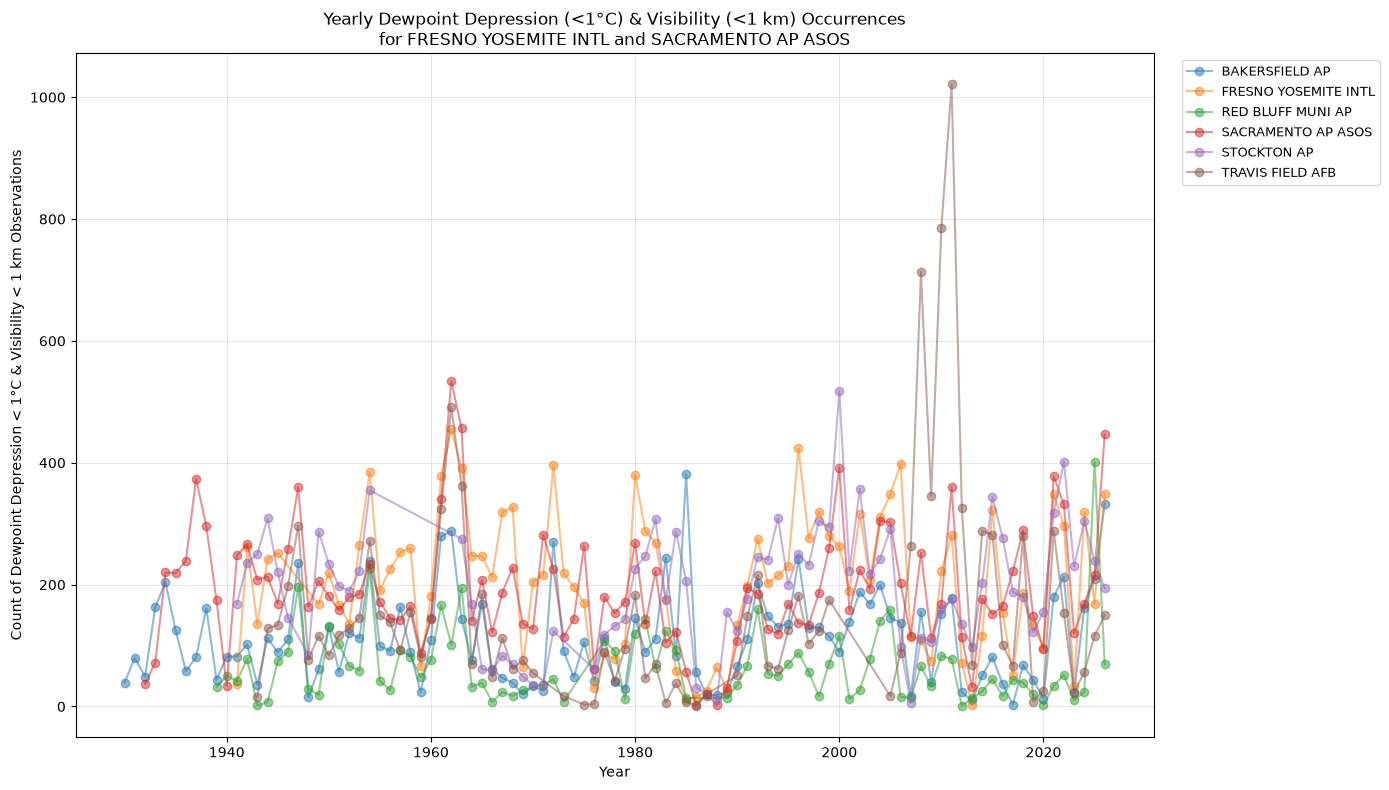

In [58]:
# Repeat the fog analysis for only the FRESNO YOSEMITE INTL and SACRAMENTO AP ASOS stations

station_names = ["BAKERSFIELD AP", "FRESNO YOSEMITE INTL", "RED BLUFF MUNI AP", "SACRAMENTO AP ASOS", "STOCKTON AP", "TRAVIS FIELD AFB"]

# Restrict the full dataset to the selected stations
CV_rows_selected = CV_rows[CV_rows["STATION"].isin(station_names)].copy()

# Ensure dewpoint depression exists
if "HourlyDewpointDepression" not in CV_rows_selected.columns:
    CV_rows_selected["HourlyDewpointDepression"] = (
        CV_rows_selected["HourlyDryBulbTemperature"] - CV_rows_selected["HourlyDewPointTemperature"]
    )

print("Selected station rows:", CV_rows_selected.shape)
print(CV_rows_selected["STATION"].value_counts())

# ------------------------------------------------------------------
# Optimal fog condition filter: dewpoint depression < 4.6 and wind < 2
# ------------------------------------------------------------------
CV_rows_selected_dd_wind_filtered = CV_rows_selected[
    (CV_rows_selected["HourlyDewpointDepression"] < 4.6)
    & (CV_rows_selected["HourlyWindSpeed"] < 2.0)
].copy()

CV_rows_selected_dd_wind_filtered = CV_rows_selected_dd_wind_filtered.drop_duplicates(subset=["STATION", "year", "month", "day", "hour"], keep="first")

print("\nOptimal fog condition rows (DD < 4.6 & wind < 2 m/s):", CV_rows_selected_dd_wind_filtered.shape)

# ------------------------------------------------------------------
# Visibility-based filters for multiple thresholds
# ------------------------------------------------------------------
CV_rows_selected_dd_filtered_5deg = CV_rows_selected[
    (CV_rows_selected["HourlyDewpointDepression"] < 5.0)
    & (CV_rows_selected["HourlyVisibility"] < 1.0)
].copy()

CV_rows_selected_dd_filtered_4deg = CV_rows_selected[
    (CV_rows_selected["HourlyDewpointDepression"] < 4.0)
    & (CV_rows_selected["HourlyVisibility"] < 1.0)
].copy()

CV_rows_selected_dd_filtered_3deg = CV_rows_selected[
    (CV_rows_selected["HourlyDewpointDepression"] < 3.0)
    & (CV_rows_selected["HourlyVisibility"] < 1.0)
].copy()

CV_rows_selected_dd_filtered_2deg = CV_rows_selected[
    (CV_rows_selected["HourlyDewpointDepression"] < 2.0)
    & (CV_rows_selected["HourlyVisibility"] < 1.0)
].copy()

CV_rows_selected_dd_filtered_1deg = CV_rows_selected[
    (CV_rows_selected["HourlyDewpointDepression"] < 1.0)
    & (CV_rows_selected["HourlyVisibility"] < 1.0)
].copy()

for name, df in {
    "CV_rows_selected_dd_filtered_5deg": CV_rows_selected_dd_filtered_5deg,
    "CV_rows_selected_dd_filtered_4deg": CV_rows_selected_dd_filtered_4deg,
    "CV_rows_selected_dd_filtered_3deg": CV_rows_selected_dd_filtered_3deg,
    "CV_rows_selected_dd_filtered_2deg": CV_rows_selected_dd_filtered_2deg,
    "CV_rows_selected_dd_filtered_1deg": CV_rows_selected_dd_filtered_1deg,
}.items():
    print(f"\n{name}: {df.shape}")

# ------------------------------------------------------------------
# Station-level valley wind type summary
# ------------------------------------------------------------------
selected_valley_counts = (
    CV_rows_selected.groupby(["STATION", "valley_wind_type"])
    .size()
    .unstack(fill_value=0)
)

print("\nSelected station valley wind counts:")
print(selected_valley_counts)

# ------------------------------------------------------------------
# Yearly counts and trend plots for the visibility-based threshold
# ------------------------------------------------------------------
# Use the 1-degree filter as the main "fog occurrence" count
yearly_counts_selected = (
    CV_rows_selected_dd_filtered_1deg.groupby(["STATION", "year"])
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(14, 8))

for station in station_names:
    station_data = yearly_counts_selected[yearly_counts_selected["STATION"] == station].sort_values("year")

    if len(station_data) < 3:
        continue

    x = station_data["year"].values
    y = station_data["count"].values

    ax.plot(x, y, marker="o", linestyle="-", alpha=0.5, label=f"{station}")

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    if p_value < 0.05:
        trend_y = slope * x + intercept
        ax.plot(
            x, trend_y, linestyle="--", linewidth=2,
            label=f"{station} trend (p={p_value:.3f}, slope={slope:.2f})"
        )

ax.set_xlabel("Year")
ax.set_ylabel("Count of Dewpoint Depression < 1°C & Visibility < 1 km Observations")
ax.set_title(
    "Yearly Dewpoint Depression (<1°C) & Visibility (<1 km) Occurrences\nfor FRESNO YOSEMITE INTL and SACRAMENTO AP ASOS"
)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


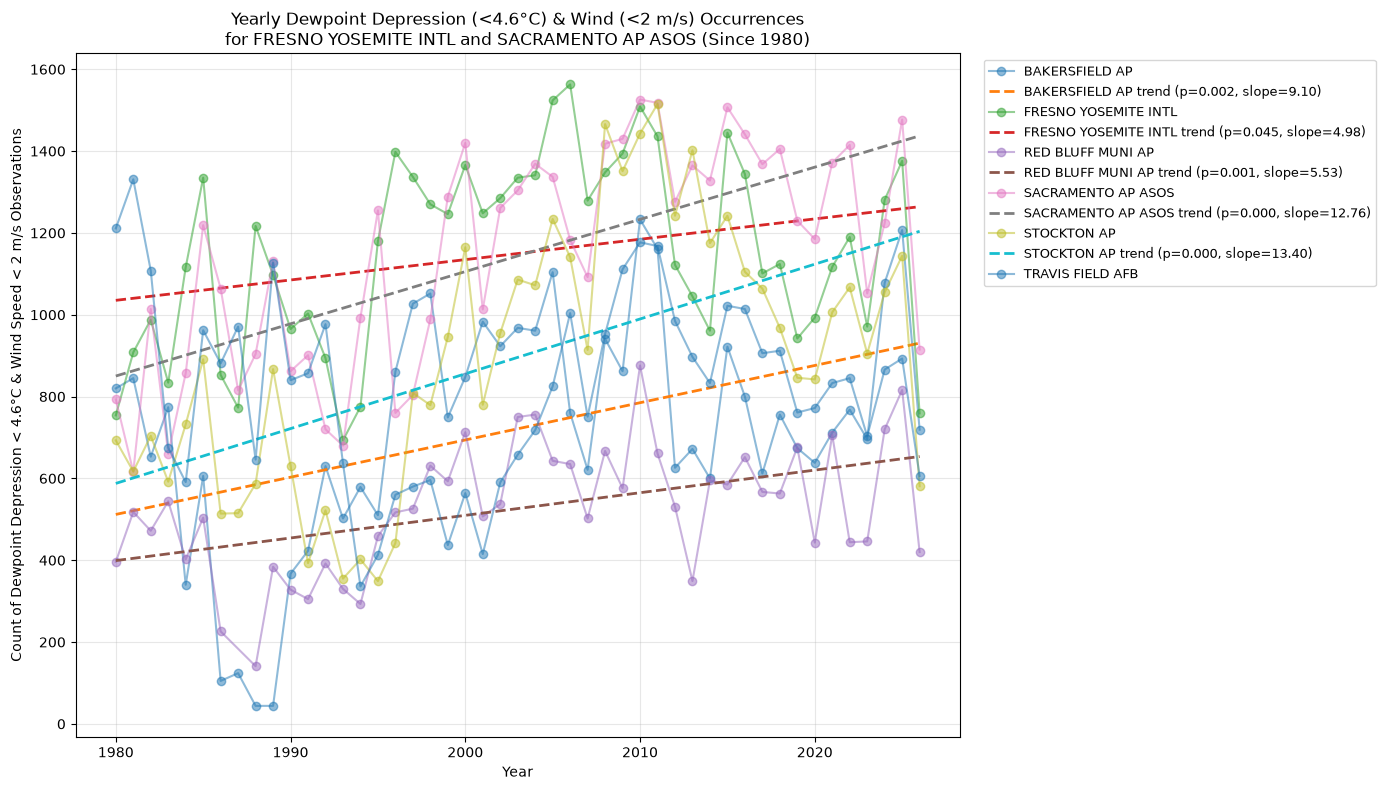


Total observations (selected stations): 2269546
Observations with optimal fog conditions (DD < 4.6 & wind < 2 m/s): 419624
Percentage of optimal fog condition observations: 18.49%

Total unique days in selected data: 19979
Unique days with at least one optimal fog condition observation: 14319
Percentage of days with optimal fog conditions: 71.67%

Optimal-fog rows with visibility < 1 km: 40706 / 419624 = 9.70%
Optimal-fog days with visibility < 1 km: 4991 / 14319 = 34.86%

Station-level optimal fog summaries:

BAKERSFIELD AP
  Total obs: 386295
  Optimal obs: 70355 (18.21%)
  Total days: 14829
  Optimal days: 11170 (75.33%)

FRESNO YOSEMITE INTL
  Total obs: 363973
  Optimal obs: 89259 (24.52%)
  Total days: 12512
  Optimal days: 11037 (88.21%)

RED BLUFF MUNI AP
  Total obs: 359261
  Optimal obs: 39643 (11.03%)
  Total days: 19678
  Optimal days: 8121 (41.27%)

SACRAMENTO AP ASOS
  Total obs: 403780
  Optimal obs: 90531 (22.42%)
  Total days: 14310
  Optimal days: 11512 (80.45%)

STO

In [59]:

# ------------------------------------------------------------------
# Yearly counts and trend plots for the wind-filtered analysis
# ------------------------------------------------------------------
yearly_counts_selected_wind = (
    CV_rows_selected_dd_wind_filtered[CV_rows_selected_dd_wind_filtered["year"] >= 1980]
    .groupby(["STATION", "year"])
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(14, 8))

for station in station_names:
    station_data = yearly_counts_selected_wind[yearly_counts_selected_wind["STATION"] == station].sort_values("year")

    if len(station_data) < 3:
        continue

    x = station_data["year"].values
    y = station_data["count"].values

    ax.plot(x, y, marker="o", linestyle="-", alpha=0.5, label=f"{station}")

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    if p_value < 0.05:
        trend_y = slope * x + intercept
        ax.plot(
            x, trend_y, linestyle="--", linewidth=2,
            label=f"{station} trend (p={p_value:.3f}, slope={slope:.2f})"
        )

ax.set_xlabel("Year")
ax.set_ylabel("Count of Dewpoint Depression < 4.6°C & Wind Speed < 2 m/s Observations")
ax.set_title(
    "Yearly Dewpoint Depression (<4.6°C) & Wind (<2 m/s) Occurrences\nfor FRESNO YOSEMITE INTL and SACRAMENTO AP ASOS (Since 1980)"
)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Optimal fog summary for the selected stations
# ------------------------------------------------------------------
total_obs_selected = CV_rows_selected.shape[0]
optimal_obs_selected = CV_rows_selected_dd_wind_filtered.shape[0]

print(f"\nTotal observations (selected stations): {total_obs_selected}")
print(f"Observations with optimal fog conditions (DD < 4.6 & wind < 2 m/s): {optimal_obs_selected}")
print(f"Percentage of optimal fog condition observations: {optimal_obs_selected / total_obs_selected * 100:.2f}%")

optimal_days_selected = CV_rows_selected_dd_wind_filtered[["year", "month", "day"]].drop_duplicates().shape[0]
total_days_selected = CV_rows_selected[["year", "month", "day"]].drop_duplicates().shape[0]

print(f"\nTotal unique days in selected data: {total_days_selected}")
print(f"Unique days with at least one optimal fog condition observation: {optimal_days_selected}")
print(f"Percentage of days with optimal fog conditions: {optimal_days_selected / total_days_selected * 100:.2f}%")

# Fraction of optimal-fog rows and days with visibility < 1 km
optimal_rows_selected = CV_rows_selected_dd_wind_filtered.copy()
vis_lt_1_rows_selected = optimal_rows_selected[optimal_rows_selected["HourlyVisibility"] < 1].copy()
frac_rows_vis_lt_1_selected = vis_lt_1_rows_selected.shape[0] / optimal_rows_selected.shape[0]

total_optimal_days_selected = optimal_rows_selected[["year", "month", "day"]].drop_duplicates().shape[0]
vis_lt_1_days_selected = vis_lt_1_rows_selected[["year", "month", "day"]].drop_duplicates().shape[0]
frac_days_vis_lt_1_selected = vis_lt_1_days_selected / total_optimal_days_selected

print(f"\nOptimal-fog rows with visibility < 1 km: {vis_lt_1_rows_selected.shape[0]} / {optimal_rows_selected.shape[0]} = {frac_rows_vis_lt_1_selected:.2%}")
print(f"Optimal-fog days with visibility < 1 km: {vis_lt_1_days_selected} / {total_optimal_days_selected} = {frac_days_vis_lt_1_selected:.2%}")

# ------------------------------------------------------------------
# Station-by-station breakdown
# ------------------------------------------------------------------
print("\nStation-level optimal fog summaries:")
for station in station_names:
    df_station = CV_rows_selected[CV_rows_selected["STATION"] == station]
    df_opt = CV_rows_selected_dd_wind_filtered[CV_rows_selected_dd_wind_filtered["STATION"] == station]
    total_obs = df_station.shape[0]
    optimal_obs = df_opt.shape[0]
    optimal_days = df_opt[["year", "month", "day"]].drop_duplicates().shape[0]
    total_days = df_station[["year", "month", "day"]].drop_duplicates().shape[0]
    print(f"\n{station}")
    print(f"  Total obs: {total_obs}")
    print(f"  Optimal obs: {optimal_obs} ({optimal_obs/total_obs*100:.2f}%)")
    print(f"  Total days: {total_days}")
    print(f"  Optimal days: {optimal_days} ({optimal_days/total_days*100:.2f}%)")


Optimal fog condition rows (DD < 1.5 & wind < 5 m/s): (390142, 24)


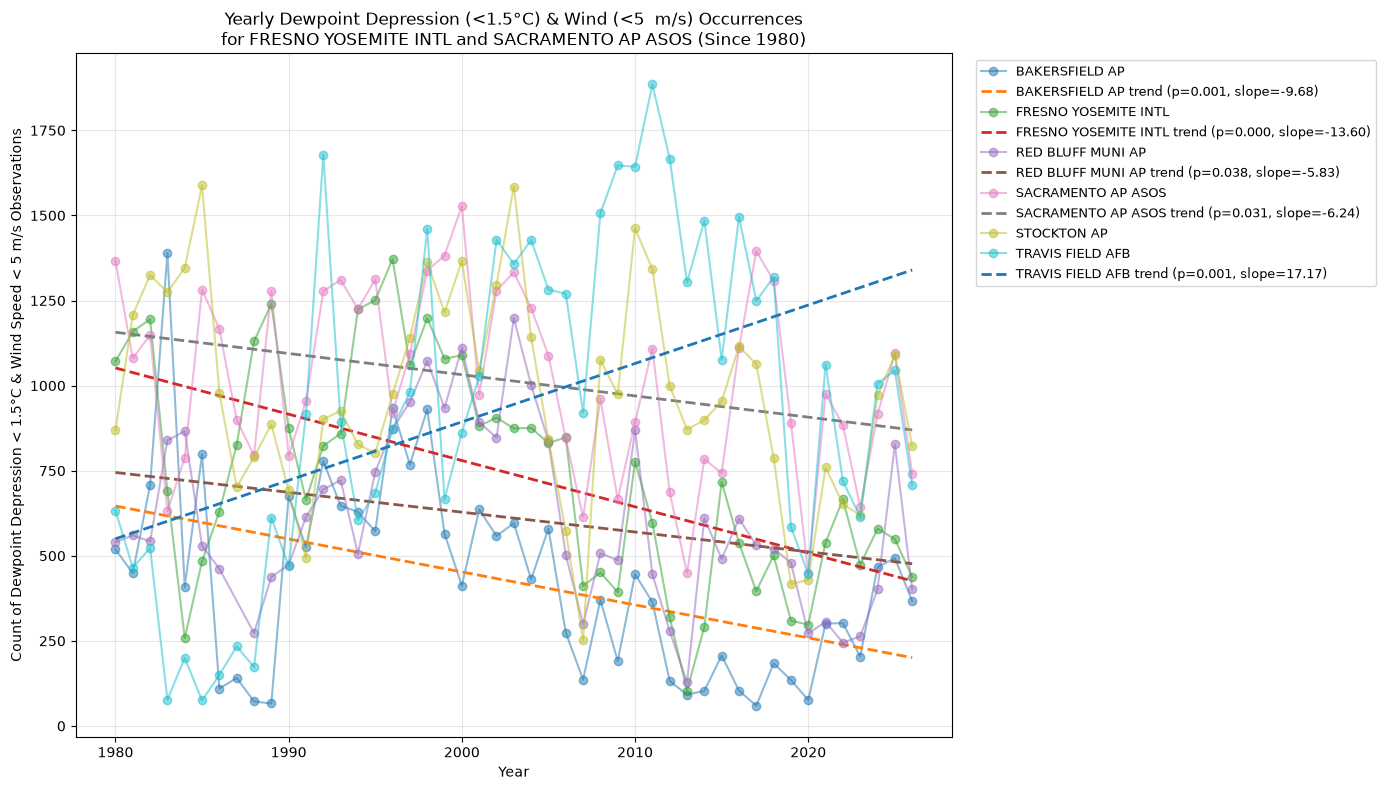

In [60]:
# ------------------------------------------------------------------
# Optimal fog condition filter: dewpoint depression < 4.6 and wind < 2
# ------------------------------------------------------------------
CV_rows_selected_dd_wind_filtered_1 = CV_rows_selected[
    (CV_rows_selected["HourlyDewpointDepression"] < 1.5)
    & (CV_rows_selected["HourlyWindSpeed"] < 5)
].copy()

# remove duplicate hours for the same day and station to avoid overcounting
CV_rows_selected_dd_wind_filtered_1 = CV_rows_selected_dd_wind_filtered_1.drop_duplicates(subset=["STATION", "year", "month", "day", "hour"], keep="first")

print("\nOptimal fog condition rows (DD < 1.5 & wind < 5 m/s):", CV_rows_selected_dd_wind_filtered_1.shape)

# ------------------------------------------------------------------
# Yearly counts and trend plots for the wind-filtered analysis
# ------------------------------------------------------------------
yearly_counts_selected_wind_1 = (
    CV_rows_selected_dd_wind_filtered_1[CV_rows_selected_dd_wind_filtered_1["year"] >= 1980]
    .groupby(["STATION", "year"])
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(14, 8))

for station in station_names:
    station_data = yearly_counts_selected_wind_1[yearly_counts_selected_wind_1["STATION"] == station].sort_values("year")

    if len(station_data) < 3:
        continue

    x = station_data["year"].values
    y = station_data["count"].values

    ax.plot(x, y, marker="o", linestyle="-", alpha=0.5, label=f"{station}")

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    if p_value < 0.05:
        trend_y = slope * x + intercept
        ax.plot(
            x, trend_y, linestyle="--", linewidth=2,
            label=f"{station} trend (p={p_value:.3f}, slope={slope:.2f})"
        )

ax.set_xlabel("Year")
ax.set_ylabel("Count of Dewpoint Depression < 1.5°C & Wind Speed < 5 m/s Observations")
ax.set_title(
    "Yearly Dewpoint Depression (<1.5°C) & Wind (<5  m/s) Occurrences\nfor FRESNO YOSEMITE INTL and SACRAMENTO AP ASOS (Since 1980)"
)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



Optimal fog condition rows (DD < 4.6): (1077660, 24)


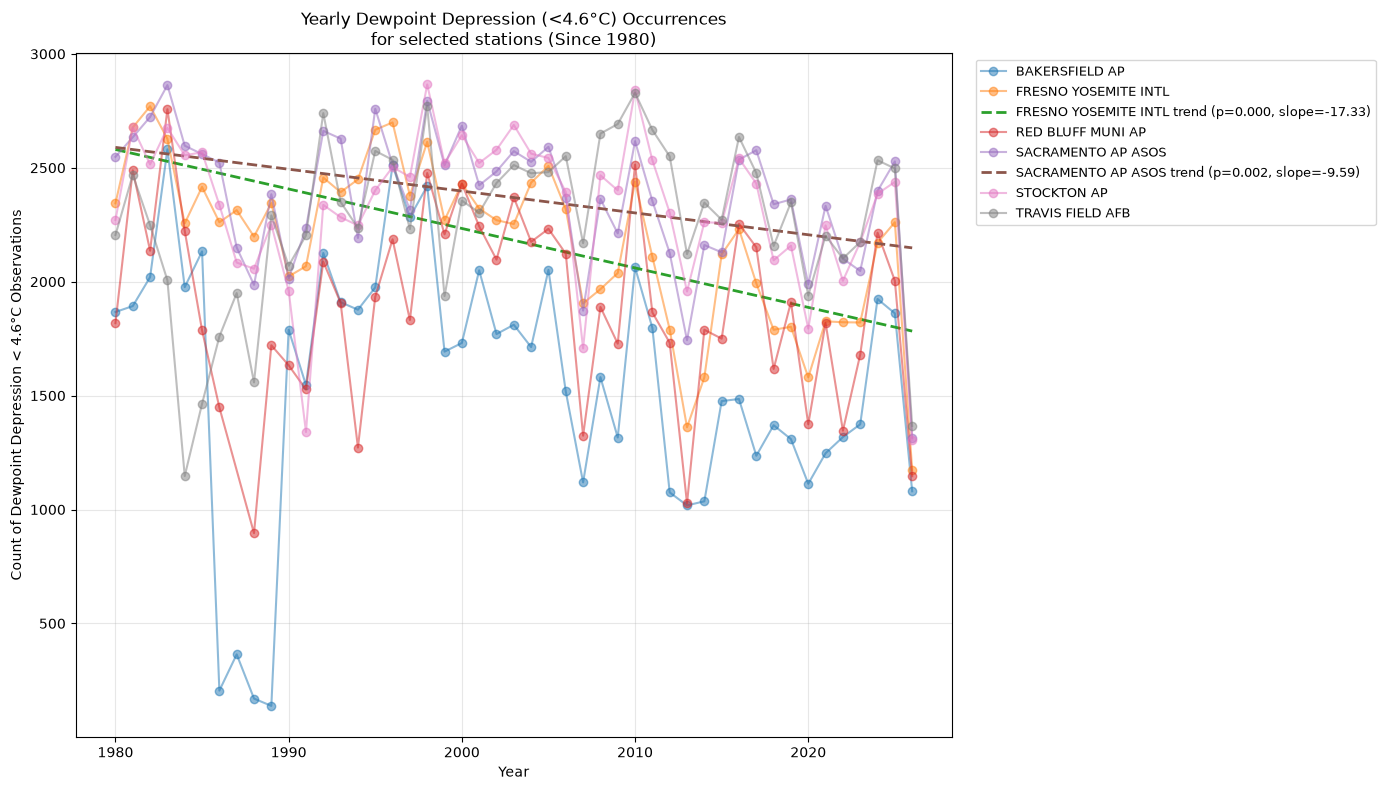

In [61]:
# ------------------------------------------------------------------
# Optimal fog condition filter: dewpoint depression < 4.6 
# ------------------------------------------------------------------
CV_rows_selected_dd_nowind_filtered = CV_rows_selected[CV_rows_selected["HourlyDewpointDepression"] < 4.6].copy()

# remove duplicate hours for the same day and station to avoid overcounting
CV_rows_selected_dd_nowind_filtered = CV_rows_selected_dd_nowind_filtered.drop_duplicates(subset=["STATION", "year", "month", "day", "hour"], keep="first")

print("\nOptimal fog condition rows (DD < 4.6):", CV_rows_selected_dd_nowind_filtered.shape)

# ------------------------------------------------------------------
# Yearly counts and trend plots for the dewpoint depression < 4.6 analysis
# ------------------------------------------------------------------
yearly_counts_selected_dd_nowind = (
    CV_rows_selected_dd_nowind_filtered[CV_rows_selected_dd_nowind_filtered["year"] >= 1980]
    .groupby(["STATION", "year"])
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(14, 8))

for station in station_names:
    station_data = yearly_counts_selected_dd_nowind[yearly_counts_selected_dd_nowind["STATION"] == station].sort_values("year")

    if len(station_data) < 3:
        continue

    x = station_data["year"].values
    y = station_data["count"].values

    ax.plot(x, y, marker="o", linestyle="-", alpha=0.5, label=f"{station}")

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    if p_value < 0.05:
        trend_y = slope * x + intercept
        ax.plot(
            x, trend_y, linestyle="--", linewidth=2,
            label=f"{station} trend (p={p_value:.3f}, slope={slope:.2f})"
        )

ax.set_xlabel("Year")
ax.set_ylabel("Count of Dewpoint Depression < 4.6°C Observations")
ax.set_title(
    "Yearly Dewpoint Depression (<4.6°C) Occurrences\nfor selected stations (Since 1980)"
)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


                STATION  ideal_days  fog_days  fog_fraction
0        BAKERSFIELD AP       11170      1587      0.142077
1  FRESNO YOSEMITE INTL       11037      2119      0.191991
2     RED BLUFF MUNI AP        8121       786      0.096786
3    SACRAMENTO AP ASOS       11512      2447      0.212561
4           STOCKTON AP        9006      1804      0.200311
5      TRAVIS FIELD AFB        9627      1407      0.146151


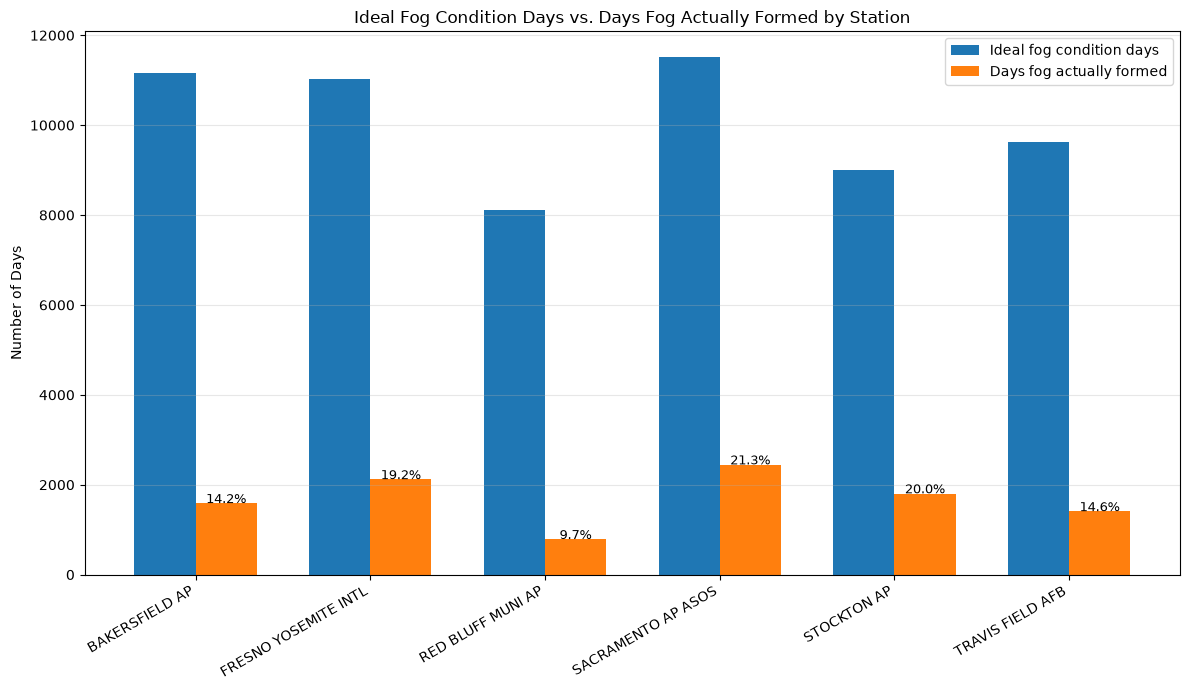

In [62]:
# For each selected station, compute the number of "ideal fog condition" days
# (DewpointDepression < 4.6 & WindSpeed < 2) and how many of those days actually
# had fog (Visibility < 1), then plot the fraction per station.

ideal_days_list = []
fog_days_list = []

for station in station_names:
    station_ideal = CV_rows_selected_dd_wind_filtered[
        CV_rows_selected_dd_wind_filtered["STATION"] == station
    ]

    ideal_days = station_ideal[["year", "month", "day"]].drop_duplicates().shape[0]

    station_fog = station_ideal[station_ideal["HourlyVisibility"] < 1]
    fog_days = station_fog[["year", "month", "day"]].drop_duplicates().shape[0]

    ideal_days_list.append(ideal_days)
    fog_days_list.append(fog_days)

station_fog_summary = pd.DataFrame({
    "STATION": station_names,
    "ideal_days": ideal_days_list,
    "fog_days": fog_days_list,
})

station_fog_summary["fog_fraction"] = (
    station_fog_summary["fog_days"] / station_fog_summary["ideal_days"]
)

print(station_fog_summary)

# ------------------------------------------------------------------
# Plot: fog days vs ideal condition days per station
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 7))

x_pos = np.arange(len(station_names))
width = 0.35

ax.bar(x_pos - width/2, station_fog_summary["ideal_days"], width, label="Ideal fog condition days")
ax.bar(x_pos + width/2, station_fog_summary["fog_days"], width, label="Days fog actually formed")

ax.set_xticks(x_pos)
ax.set_xticklabels(station_names, rotation=30, ha="right")
ax.set_ylabel("Number of Days")
ax.set_title("Ideal Fog Condition Days vs. Days Fog Actually Formed by Station")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# Annotate fog fraction on top of each fog_days bar
for i, frac in enumerate(station_fog_summary["fog_fraction"]):
    ax.text(
        x_pos[i] + width/2,
        station_fog_summary["fog_days"].iloc[i] + 5,
        f"{frac:.1%}",
        ha="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

          STATION  year  ideal_days  fog_days  fog_fraction
0  BAKERSFIELD AP  1930          96      11.0      0.114583
1  BAKERSFIELD AP  1931         124      21.0      0.169355
2  BAKERSFIELD AP  1932         122      10.0      0.081967
3  BAKERSFIELD AP  1933         110      16.0      0.145455
4  BAKERSFIELD AP  1934         120      35.0      0.291667


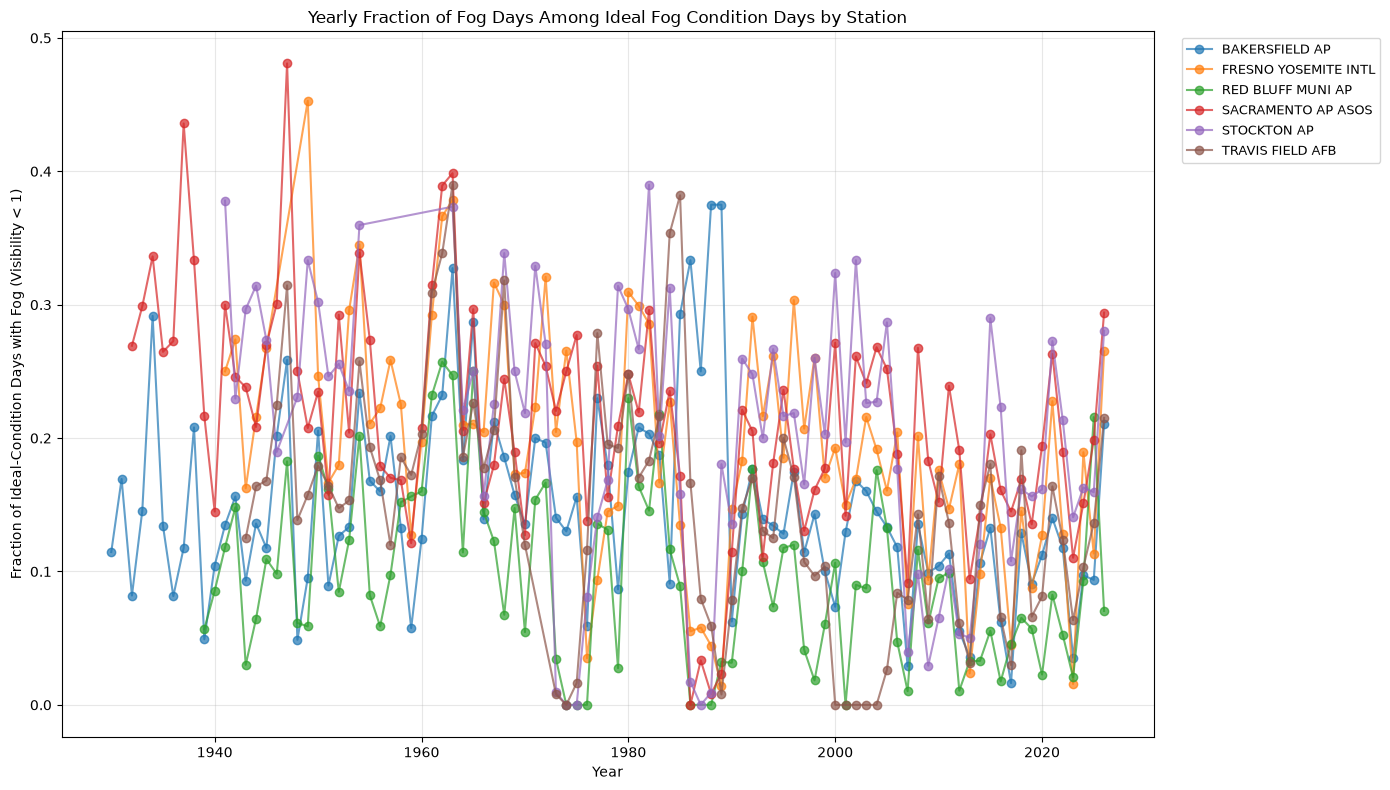

In [63]:
# Compute per-year, per-station counts of ideal fog condition days and
# actual fog days (visibility < 1), then plot the fraction over time.

ideal_days_by_year = (
    CV_rows_selected_dd_wind_filtered
    .groupby(["STATION", "year"])[["year", "month", "day"]]
    .apply(lambda df: df.drop_duplicates(subset=["year", "month", "day"]).shape[0])
    .reset_index(name="ideal_days")
)

fog_actual = CV_rows_selected_dd_wind_filtered[
    CV_rows_selected_dd_wind_filtered["HourlyVisibility"] < 1
]

fog_days_by_year = (
    fog_actual
    .groupby(["STATION", "year"])[["year", "month", "day"]]
    .apply(lambda df: df.drop_duplicates(subset=["year", "month", "day"]).shape[0])
    .reset_index(name="fog_days")
)

fog_ratio_by_year = pd.merge(
    ideal_days_by_year, fog_days_by_year, on=["STATION", "year"], how="left"
)
fog_ratio_by_year["fog_days"] = fog_ratio_by_year["fog_days"].fillna(0)
fog_ratio_by_year["fog_fraction"] = (
    fog_ratio_by_year["fog_days"] / fog_ratio_by_year["ideal_days"]
)

print(fog_ratio_by_year.head())

# ------------------------------------------------------------------
# Plot fog_fraction per year for each station
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 8))

for station in station_names:
    station_data = fog_ratio_by_year[
        fog_ratio_by_year["STATION"] == station
    ].sort_values("year")

    if len(station_data) < 3:
        continue

    ax.plot(
        station_data["year"],
        station_data["fog_fraction"],
        marker="o",
        linestyle="-",
        alpha=0.7,
        label=station,
    )

ax.set_xlabel("Year")
ax.set_ylabel("Fraction of Ideal-Condition Days with Fog (Visibility < 1)")
ax.set_title("Yearly Fraction of Fog Days Among Ideal Fog Condition Days by Station")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Trend summary:
                STATION  n_years  slope_per_year  intercept   r_value  \
1  FRESNO YOSEMITE INTL       83       -0.001683   3.533883 -0.471731   
3    SACRAMENTO AP ASOS       95       -0.001286   2.758041 -0.424780   
5      TRAVIS FIELD AFB       82       -0.001573   3.269381 -0.424447   
4           STOCKTON AP       77       -0.001455   3.093351 -0.355446   
2     RED BLUFF MUNI AP       87       -0.000826   1.735559 -0.321657   
0        BAKERSFIELD AP       97       -0.000486   1.110109 -0.189588   

    p_value   std_err  significant_p_lt_0_05  
1  0.000007  0.000349                   True  
3  0.000018  0.000284                   True  
5  0.000071  0.000375                   True  
4  0.001512  0.000442                   True  
2  0.002382  0.000264                   True  
0  0.062896  0.000258                  False  

Significant trends (p < 0.05):
                STATION  n_years  slope_per_year  intercept   r_value  \
1  FRESNO YOSEMITE INTL       83       

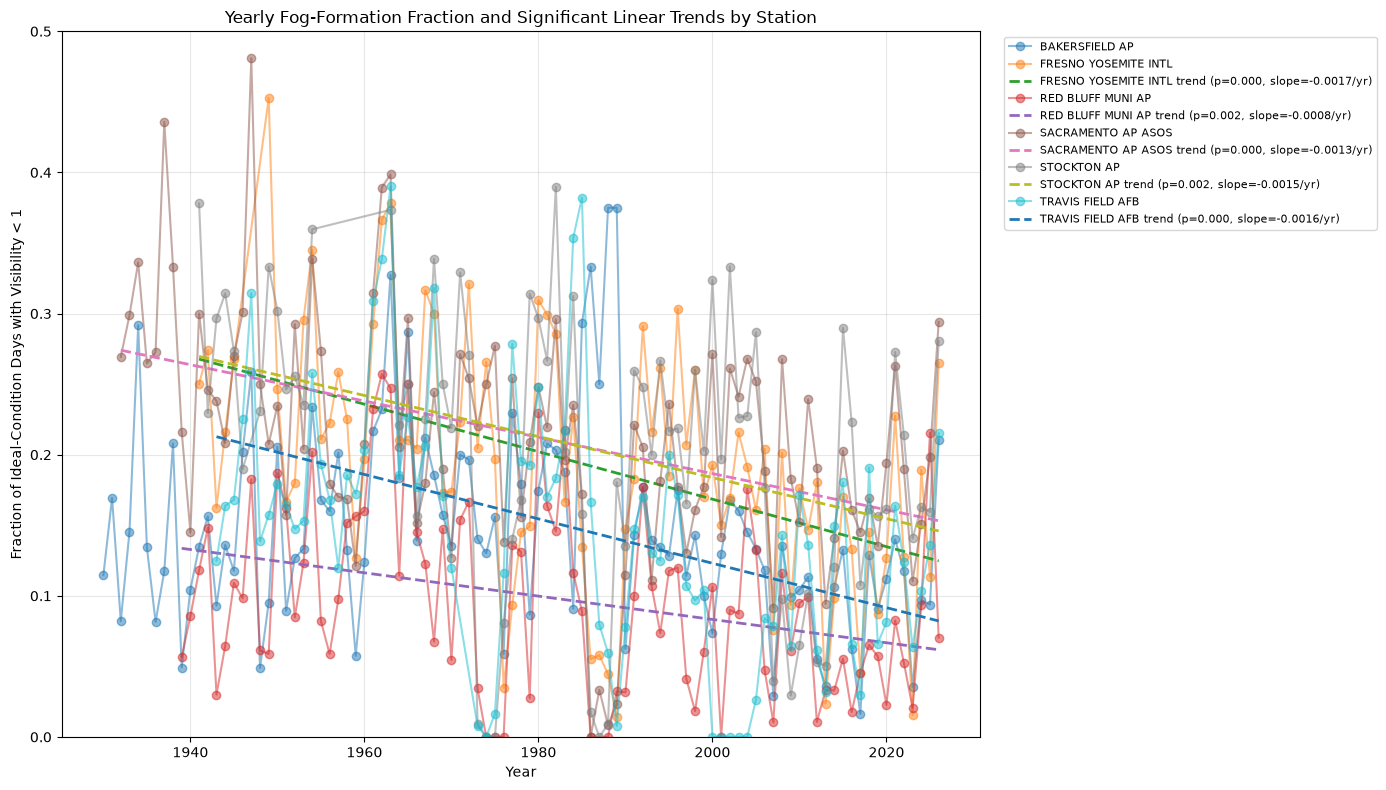

In [64]:
# Trend analysis: fraction of ideal-condition days with visibility < 1 by station
# Uses fog_ratio_by_year from earlier cells (columns: STATION, year, ideal_days, fog_days, fog_fraction)

trend_rows = []

fig, ax = plt.subplots(figsize=(14, 8))

for station in station_names:
    station_data = (
        fog_ratio_by_year[fog_ratio_by_year["STATION"] == station]
        .sort_values("year")
        .copy()
    )

    # keep valid fraction rows only
    station_data = station_data[np.isfinite(station_data["fog_fraction"])]

    if len(station_data) < 3:
        continue

    x = station_data["year"].to_numpy()
    y = station_data["fog_fraction"].to_numpy()

    # plot yearly fraction
    ax.plot(x, y, marker="o", linestyle="-", alpha=0.5, label=f"{station}")

    # linear trend
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    significant = np.isfinite(p_value) and (p_value < 0.05)

    trend_rows.append(
        {
            "STATION": station,
            "n_years": len(station_data),
            "slope_per_year": slope,
            "intercept": intercept,
            "r_value": r_value,
            "p_value": p_value,
            "std_err": std_err,
            "significant_p_lt_0_05": significant,
        }
    )

    # plot only significant trend lines
    if significant:
        trend_y = slope * x + intercept
        ax.plot(
            x, trend_y, linestyle="--", linewidth=2,
            label=f"{station} trend (p={p_value:.3f}, slope={slope:.4f}/yr)"
        )

trend_summary = pd.DataFrame(trend_rows).sort_values("p_value")
print("Trend summary:")
print(trend_summary)

print("\nSignificant trends (p < 0.05):")
print(trend_summary[trend_summary["significant_p_lt_0_05"]])

ax.set_xlabel("Year")
ax.set_ylabel("Fraction of Ideal-Condition Days with Visibility < 1")
ax.set_title("Yearly Fog-Formation Fraction and Significant Linear Trends by Station")
ax.set_ylim(0, 0.5)
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)

plt.tight_layout()
plt.show()

                STATION  n_years  slope_per_year   p_value  \
0        BAKERSFIELD AP       47       -0.003213  0.000063   
2     RED BLUFF MUNI AP       46       -0.001323  0.040930   
5      TRAVIS FIELD AFB       47       -0.001827  0.044131   
1  FRESNO YOSEMITE INTL       47       -0.001655  0.050404   
4           STOCKTON AP       47       -0.001187  0.246183   
3    SACRAMENTO AP ASOS       47        0.000647  0.411480   

   significant_p_lt_0_05  
0                   True  
2                   True  
5                   True  
1                  False  
4                  False  
3                  False  


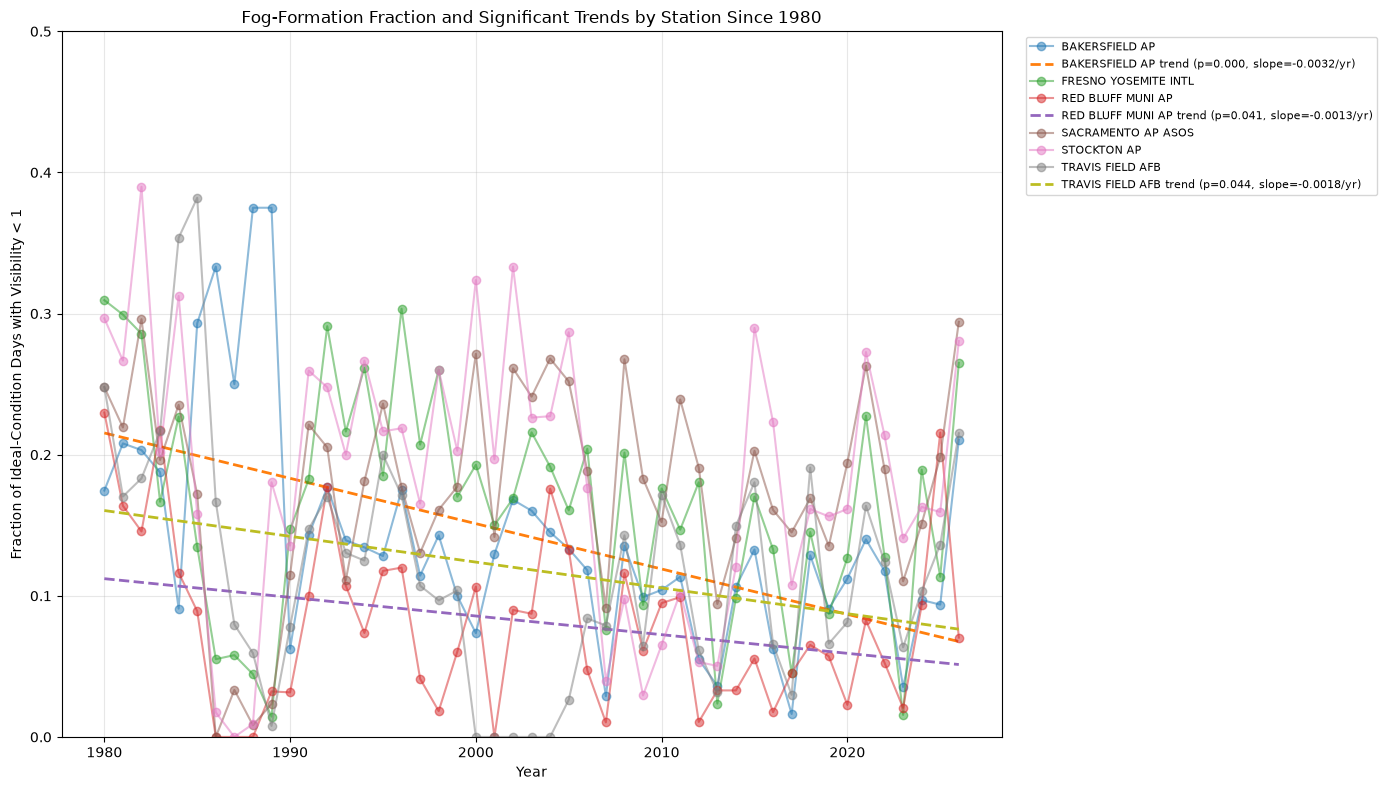

In [65]:
# Trend analysis since 1980: fraction of ideal-condition days with visibility < 1

trend_rows_since_1980 = []

fig, ax = plt.subplots(figsize=(14, 8))

for station in station_names:
    station_data_since_1980 = (
        fog_ratio_by_year[
            (fog_ratio_by_year["STATION"] == station)
            & (fog_ratio_by_year["year"] >= 1980)
        ]
        .dropna(subset=["fog_fraction"])
        .sort_values("year")
    )

    if len(station_data_since_1980) < 3:
        continue

    x = station_data_since_1980["year"].to_numpy()
    y = station_data_since_1980["fog_fraction"].to_numpy()

    ax.plot(x, y, marker="o", linestyle="-", alpha=0.5, label=station)

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    significant = p_value < 0.05

    trend_rows_since_1980.append({
        "STATION": station,
        "n_years": len(station_data_since_1980),
        "slope_per_year": slope,
        "p_value": p_value,
        "significant_p_lt_0_05": significant,
    })

    if significant:
        ax.plot(
            x, slope * x + intercept,
            linestyle="--",
            linewidth=2,
            label=f"{station} trend (p={p_value:.3f}, slope={slope:.4f}/yr)",
        )

trend_summary_since_1980 = pd.DataFrame(trend_rows_since_1980).sort_values("p_value")
print(trend_summary_since_1980)

ax.set_xlabel("Year")
ax.set_ylabel("Fraction of Ideal-Condition Days with Visibility < 1")
ax.set_title("Fog-Formation Fraction and Significant Trends by Station Since 1980")
ax.set_ylim(0, 0.5)
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)

plt.tight_layout()
plt.show()

                STATION  n_years  slope_per_year   p_value  \
4           STOCKTON AP       30       -0.004032  0.005868   
3    SACRAMENTO AP ASOS       48       -0.001835  0.024019   
1  FRESNO YOSEMITE INTL       36       -0.002360  0.058706   
0        BAKERSFIELD AP       50        0.000818  0.192424   
5      TRAVIS FIELD AFB       35       -0.001046  0.451563   
2     RED BLUFF MUNI AP       41       -0.000377  0.681918   

   significant_p_lt_0_05  
4                   True  
3                   True  
1                  False  
0                  False  
5                  False  
2                  False  


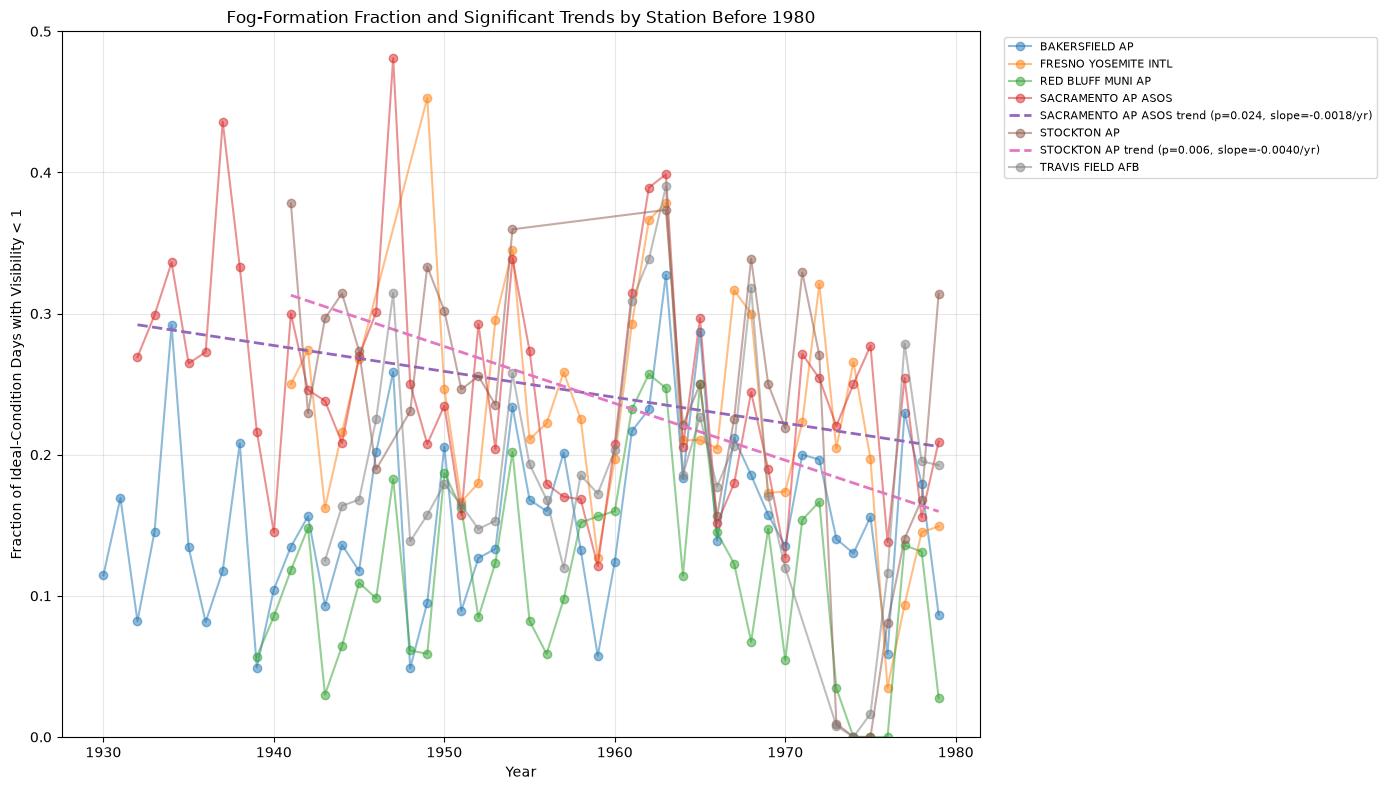

In [69]:
# Trend analysis since 1980: fraction of ideal-condition days with visibility < 1

trend_rows_pre_1980 = []

fig, ax = plt.subplots(figsize=(14, 8))

for station in station_names:
    station_data_pre_1980 = (
        fog_ratio_by_year[
            (fog_ratio_by_year["STATION"] == station)
            & (fog_ratio_by_year["year"] < 1980)
        ]
        .dropna(subset=["fog_fraction"])
        .sort_values("year")
    )

    if len(station_data_pre_1980) < 3:
        continue

    x = station_data_pre_1980["year"].to_numpy()
    y = station_data_pre_1980["fog_fraction"].to_numpy()

    ax.plot(x, y, marker="o", linestyle="-", alpha=0.5, label=station)

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    significant = p_value < 0.05

    trend_rows_pre_1980.append({
        "STATION": station,
        "n_years": len(station_data_pre_1980),
        "slope_per_year": slope,
        "p_value": p_value,
        "significant_p_lt_0_05": significant,
    })

    if significant:
        ax.plot(
            x, slope * x + intercept,
            linestyle="--",
            linewidth=2,
            label=f"{station} trend (p={p_value:.3f}, slope={slope:.4f}/yr)",
        )

trend_summary_pre_1980 = pd.DataFrame(trend_rows_pre_1980).sort_values("p_value")
print(trend_summary_pre_1980)

ax.set_xlabel("Year")
ax.set_ylabel("Fraction of Ideal-Condition Days with Visibility < 1")
ax.set_title("Fog-Formation Fraction and Significant Trends by Station Before 1980")
ax.set_ylim(0, 0.5)
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)

plt.tight_layout()
plt.show()

In [66]:
common_station_names = [
    "BAKERSFIELD AP",
    "FRESNO YOSEMITE INTL",
    "RED BLUFF MUNI AP",
    "SACRAMENTO AP ASOS",
    "STOCKTON AP",
    "TRAVIS FIELD AFB",
]

fog_rows_common = CV_rows_dd_filtered_1deg[
    CV_rows_dd_filtered_1deg["STATION"].isin(common_station_names)
].copy()

fog_rows_common["date"] = pd.to_datetime(
    fog_rows_common[["year", "month", "day"]]
)

# Summarize each station's fog observations by day
station_day_fog = (
    fog_rows_common
    .groupby(["date", "STATION"])
    .agg(
        first_observation=("DATE", "min"),
        last_observation=("DATE", "max"),
        fog_observations=("STATION", "size"),
    )
    .reset_index()
)

# Find dates affecting at least 5 of the 6 stations
common_fog_events = (
    station_day_fog
    .groupby("date")
    .agg(
        stations_with_fog=("STATION", "nunique"),
        stations=("STATION", lambda x: sorted(x.tolist())),
        total_fog_observations=("fog_observations", "sum"),
    )
    .reset_index()
)

common_fog_events = (
    common_fog_events[
        common_fog_events["stations_with_fog"] >= 5
    ]
    .sort_values("date")
    .reset_index(drop=True)
)

print(f"Common fog dates: {len(common_fog_events)}")
common_fog_events

Common fog dates: 408


,date,stations_with_fog,stations,total_fog_observations
0,1942-01-11,5,"[BAKERSFIELD AP, FRESNO YOSEMITE INTL, RED BLU...",35
1,1942-01-15,5,"[BAKERSFIELD AP, FRESNO YOSEMITE INTL, RED BLU...",30
2,1942-12-15,5,"[BAKERSFIELD AP, FRESNO YOSEMITE INTL, RED BLU...",65
3,1942-12-16,5,"[BAKERSFIELD AP, FRESNO YOSEMITE INTL, RED BLU...",73
4,1942-12-17,5,"[BAKERSFIELD AP, FRESNO YOSEMITE INTL, RED BLU...",60
...,...,...,...,...
403,2026-01-20,6,"[BAKERSFIELD AP, FRESNO YOSEMITE INTL, RED BLU...",104
404,2026-01-21,6,"[BAKERSFIELD AP, FRESNO YOSEMITE INTL, RED BLU...",70
405,2026-01-22,5,"[BAKERSFIELD AP, FRESNO YOSEMITE INTL, RED BLU...",83
406,2026-01-23,6,"[BAKERSFIELD AP, FRESNO YOSEMITE INTL, RED BLU...",94


In [67]:
fog_days_per_year = (
    common_fog_events.assign(
        year=pd.to_datetime(common_fog_events["date"]).dt.year
    )
    .groupby("year")
    .size()
    .reset_index(name="fog_days")
)

fog_days_per_year

,year,fog_days
0,1942,5
1,1943,1
2,1944,8
3,1945,6
4,1949,7
...,...,...
61,2021,4
62,2022,4
63,2024,2
64,2025,4


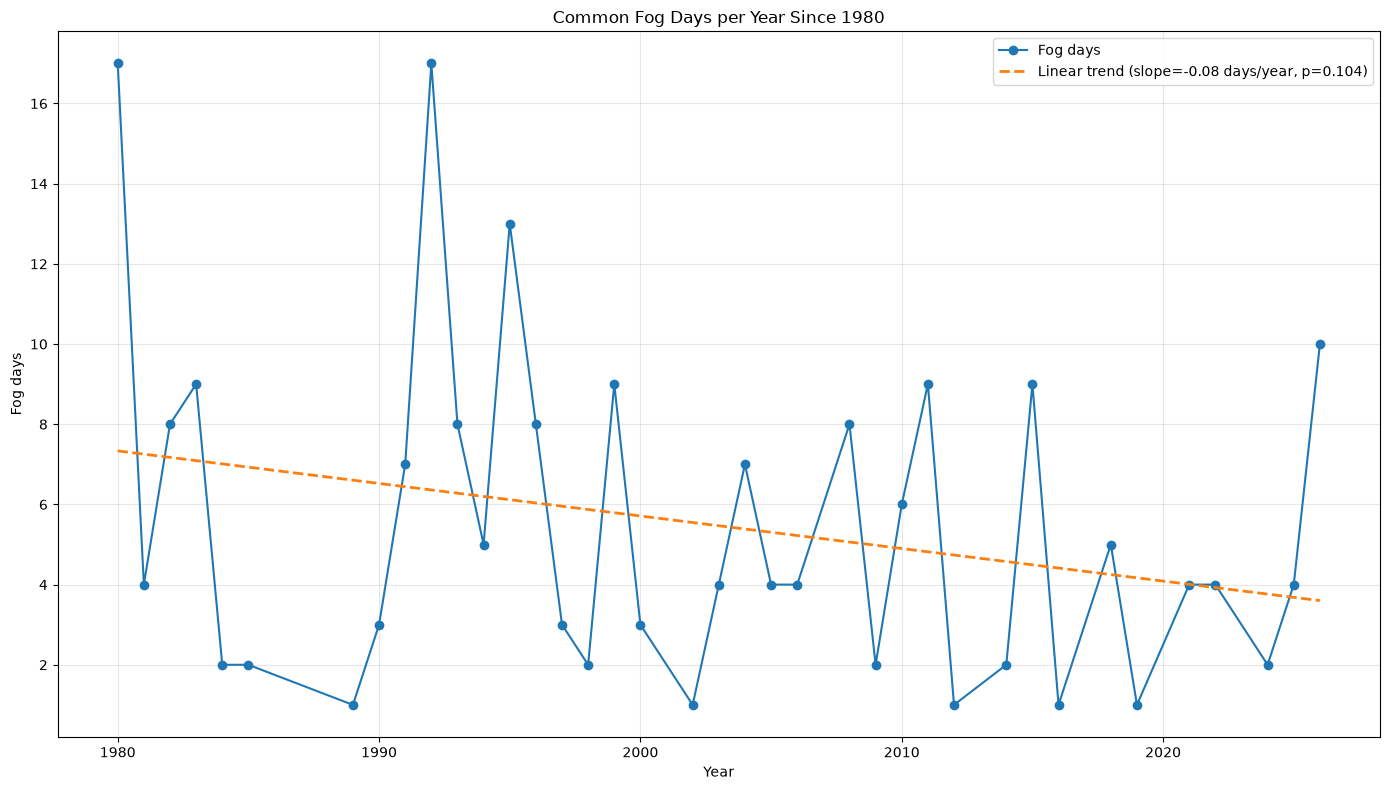

In [68]:
fog_days_since_1980 = fog_days_per_year[
    fog_days_per_year["year"] >= 1980
].sort_values("year")

x_fog = fog_days_since_1980["year"].to_numpy()
y_fog = fog_days_since_1980["fog_days"].to_numpy()

fog_slope, fog_intercept, _, fog_p_value, _ = stats.linregress(x_fog, y_fog)
fog_trend = fog_slope * x_fog + fog_intercept

fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(x_fog, y_fog, marker="o", linestyle="-", label="Fog days")
ax.plot(
    x_fog,
    fog_trend,
    linestyle="--",
    linewidth=2,
    label=f"Linear trend (slope={fog_slope:.2f} days/year, p={fog_p_value:.3f})"
)

ax.set_xlabel("Year")
ax.set_ylabel("Fog days")
ax.set_title("Common Fog Days per Year Since 1980")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()